# 01: Regional Pathogenicity Mapping & Statistical Analysis

This notebook performs the regional pathogenicity analysis across 14 human GLUT transporters (*SLC2A1–SLC2A14*).

### Pipeline:
1. Define the 14 GLUT transporters across Group I, Group II, and Group III.
2. Extract structural regions: transmembrane (TM), intracellular, extracellular, pore lining, and binding site.
3. Map AlphaMissense, PolyPhen-2, and SIFT scores to each region.
4. Generate regional heatmaps (**Figure 3**).
5. Execute pairwise paired $t$-tests and compute 95% Confidence Intervals (**Figure 4**).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Add src directory to path
src_path = Path.cwd().parent / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import analyze_variant_impact as avi
import visualization as viz

## 1. Load Real Regional Pathogenicity Scores

In [2]:
data_dir = Path.cwd().parent / 'data' / 'statistics'
datasets = avi.load_all_datasets(data_dir)

for name, df in datasets.items():
    print(f'=== {name} (N={len(df)}) ===')
    display(df.head(3))

=== PolyPhen (N=14) ===


,protein,average for protein,binding place,lining residues,lining residues without binding place,transmembrane region,intracellular domain,extracellular domain,Dataset
0,GLUT1,0.732,0.908,0.829,0.78755,0.786,0.722,0.528,PolyPhen
1,GLUT2,0.689,0.672,0.814,0.77330,0.773,0.725,0.430,PolyPhen
2,GLUT3,0.780,0.954,0.952,0.90440,0.840,0.780,0.556,PolyPhen


=== AlphaMissense (N=14) ===


,protein,average for protein,binding place,lining residues,lining residues without binding place,transmembrane region,intracellular domain,extracellular domain,Dataset
0,GLUT1,0.670,0.844,0.767,0.72865,0.720,0.643,0.504,AlphaMissense
1,GLUT2,0.501,0.463,0.614,0.58330,0.579,0.483,0.314,AlphaMissense
2,GLUT3,0.658,0.864,0.869,0.82555,0.726,0.613,0.465,AlphaMissense


=== SIFT (N=14) ===


,protein,average for protein,binding place,lining residues,lining residues without binding place,transmembrane region,intracellular domain,extracellular domain,Dataset
0,GLUT1,0.105,0.057,0.079,0.08295,0.079,0.125,0.180,SIFT
1,GLUT2,0.109,0.142,0.072,0.07560,0.075,0.105,0.200,SIFT
2,GLUT3,0.099,0.048,0.056,0.05880,0.074,0.117,0.169,SIFT


## 2. Statistical Analysis & Grouped Bar Chart (Figure 4)

Runs pairwise paired $t$-tests and generates Figure 4 with significance brackets.

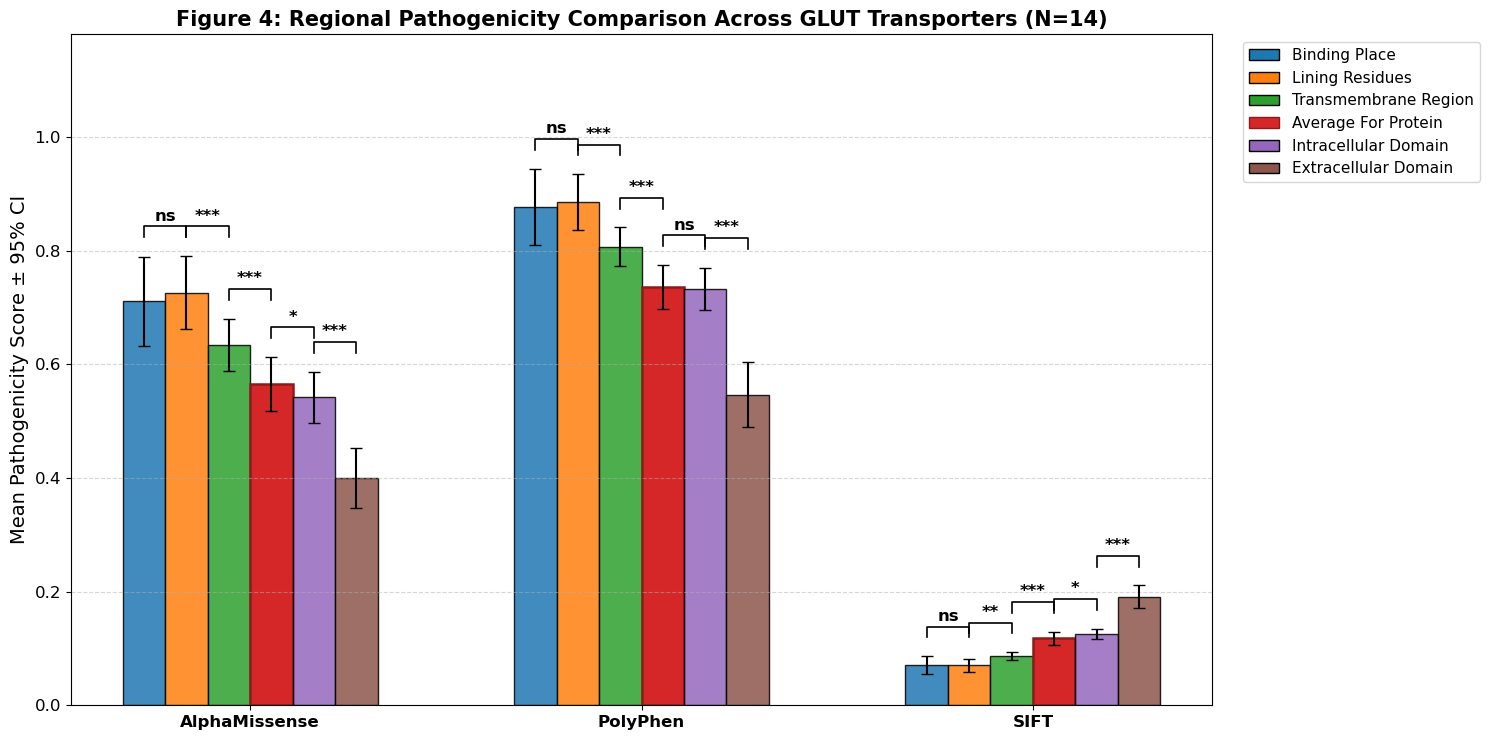

In [3]:
long_df = avi.to_long_format(datasets)
summary_df = avi.compute_group_stats(long_df)
dataset_names = list(datasets.keys())

# 1. Neighboring comparisons & Figure 4
neighbor_pvals = avi.compute_neighbor_pvalues(long_df, dataset_names, avi.REGIONS_ORDERED)

fig_out = Path.cwd().parent / 'results' / 'figures' / 'figure4_region_comparison_bars.png'
avi.plot_grouped_bars_with_neighbor_significance(summary_df, neighbor_pvals, output_path=fig_out, show=True)

## 3. Summary Statistics Table

In [4]:
display(summary_df)

,Dataset,Region,Mean,SEM,CI,N
0,AlphaMissense,binding place,0.711571,0.036253,0.078321,14
1,AlphaMissense,lining residues,0.726286,0.029936,0.064673,14
2,AlphaMissense,transmembrane region,0.634714,0.021118,0.045622,14
3,AlphaMissense,average for protein,0.565929,0.021822,0.047144,14
4,AlphaMissense,intracellular domain,0.542357,0.020854,0.045052,14
5,AlphaMissense,extracellular domain,0.399857,0.024632,0.053214,14
6,PolyPhen,binding place,0.877143,0.031320,0.067663,14
7,PolyPhen,lining residues,0.886000,0.022726,0.049097,14
8,PolyPhen,transmembrane region,0.807214,0.015659,0.033830,14
9,PolyPhen,average for protein,0.736286,0.017938,0.038752,14
